# Mutation Potentials Demo

Minimal demo of `ProjectedDirectionPairwiseSimilarityPotential` and `compose_mutant_distribution` on a peptide.

In [4]:
import torch
from pep_compass.models.encoder_decoder.hydramp_encoder_decoder import (
    HydrAMPEncoderDecoder,
)
from pep_compass.models.encoder_decoder.utils import decoder_jacobian
from pep_compass.local_enumeration.mutation.utils import get_mutations_from_s_u_standard
from pep_compass.local_enumeration.sampling.sorbes import SubRiemannianTangentSpace

from pep_compass.local_enumeration.mutation.mutation_potentials import (
    compose_mutant_distribution,
    ProjectedDirectionPairwiseSimilarityPotential,
    DecoderLogProbPotential
)

In [5]:
device = torch.device("cpu")
hydramp = HydrAMPEncoderDecoder(
    jacobian_mode="approx",
    jacobian_eps=1e-6,
    field_eps=1e-6,
    device=device,
)

In [6]:
peptide = "FLYKWWIRIGRLKL"
pep_len = len(peptide)
z = hydramp.encode_peptides([peptide])
print(f"Parent: {peptide}")
print(f"Latent shape: {z.shape}")

Parent: FLYKWWIRIGRLKL
Latent shape: torch.Size([1, 64])


In [7]:
jac = decoder_jacobian(
    lambda x: hydramp.decoder_forward(x, softmax=True, flatten=True),
    z,
    jacobian_fn_mode="approx",
    jacobian_fn_kwargs={"jacobian_eps": 1e-6},
)
U, S, V = torch.linalg.svd(jac, full_matrices=False)
print(f"U shape: {U.shape}, S shape: {S.shape}, V shape: {V.shape}")

U shape: torch.Size([1, 525, 64]), S shape: torch.Size([1, 64]), V shape: torch.Size([1, 64, 64])


In [8]:
S[0].detach().cpu().numpy()

array([4.0451312e-03, 7.0609455e-04, 3.9391438e-04, 3.7333343e-04,
       2.1011812e-04, 1.6609606e-04, 1.9095794e-05, 1.4202213e-05,
       1.0694105e-05, 9.2550745e-06, 5.8253718e-06, 4.0492087e-06,
       2.9571856e-06, 2.5452664e-06, 2.1410688e-06, 1.6692513e-06,
       1.4492007e-06, 1.3206219e-06, 1.0604336e-06, 9.0314120e-07,
       7.8348864e-07, 4.4403836e-07, 2.9451937e-07, 2.3163933e-07,
       2.0342101e-07, 1.8109969e-07, 1.5192607e-07, 1.3235115e-07,
       1.1537374e-07, 9.6874174e-08, 6.0102366e-08, 5.0703214e-08,
       4.4011024e-08, 3.9289880e-08, 3.7693905e-08, 3.1962770e-08,
       2.9120763e-08, 2.1900409e-08, 1.9686487e-08, 1.7594001e-08,
       1.6995495e-08, 1.1431438e-08, 8.3884650e-09, 5.9861396e-09,
       5.4555698e-09, 5.1401612e-09, 4.3362172e-09, 3.6689869e-09,
       3.4505274e-09, 2.5976643e-09, 2.5482643e-09, 2.1889437e-09,
       1.5051600e-09, 1.2778331e-09, 8.6469443e-10, 7.9915646e-10,
       5.8156147e-10, 4.4114551e-10, 3.6779405e-10, 2.6138544e

In [9]:
mutations = get_mutations_from_s_u_standard(
    s=S[0].detach().cpu().numpy(),
    u=U[0].detach().cpu().numpy(),
    max_len=25,
    alphabet_size=21,
    direction_significance_threshold=1e-6,
    min_number_of_directions=5,
    token_threshold=1e-4,
)

alphabet = list(" ACDEFGHIKLMNPQRSTVWY")
print("Proposed mutations:")
for pos in sorted(mutations.keys()):
    aas = [alphabet[i] for i in mutations[pos]]
    print(f"  pos {pos}: indices {mutations[pos]}  ->  {aas}")

Proposed mutations:
  pos 0: indices [8, 13, 15, 20, 2, 7, 8, 13, 15, 18, 20]  ->  ['I', 'P', 'R', 'Y', 'C', 'H', 'I', 'P', 'R', 'V', 'Y']
  pos 2: indices [5, 14, 15, 5, 14, 15]  ->  ['F', 'Q', 'R', 'F', 'Q', 'R']
  pos 3: indices [14, 19, 14, 19]  ->  ['Q', 'W', 'Q', 'W']
  pos 6: indices [5, 7, 13, 17, 5, 7, 13, 17, 5, 7, 10, 13, 17]  ->  ['F', 'H', 'P', 'T', 'F', 'H', 'P', 'T', 'F', 'H', 'L', 'P', 'T']
  pos 8: indices [5, 7, 10, 12, 13, 17, 5, 7, 10, 12, 13, 17, 5, 7, 10, 12, 13, 17, 5, 7, 10, 12, 13, 17, 5, 7, 10, 12, 13, 17, 5, 7, 10, 12, 13, 17, 5, 7, 10, 12, 13, 17]  ->  ['F', 'H', 'L', 'N', 'P', 'T', 'F', 'H', 'L', 'N', 'P', 'T', 'F', 'H', 'L', 'N', 'P', 'T', 'F', 'H', 'L', 'N', 'P', 'T', 'F', 'H', 'L', 'N', 'P', 'T', 'F', 'H', 'L', 'N', 'P', 'T', 'F', 'H', 'L', 'N', 'P', 'T']
  pos 11: indices [4, 8, 9, 12, 17, 4, 8, 9, 12, 17]  ->  ['E', 'I', 'K', 'N', 'T', 'E', 'I', 'K', 'N', 'T']
  pos 12: indices [19]  ->  ['W']


In [10]:
##take only positions od pep_len
mutations = {pos: muts for pos, muts in mutations.items() if pos < pep_len}
print("\nProposed mutations (only positions within peptide length):")
for pos in sorted(mutations.keys()):
    aas = [alphabet[i] for i in mutations[pos]]
    print(f"  pos {pos}: indices {mutations[pos]}  ->  {aas}")


Proposed mutations (only positions within peptide length):
  pos 0: indices [8, 13, 15, 20, 2, 7, 8, 13, 15, 18, 20]  ->  ['I', 'P', 'R', 'Y', 'C', 'H', 'I', 'P', 'R', 'V', 'Y']
  pos 2: indices [5, 14, 15, 5, 14, 15]  ->  ['F', 'Q', 'R', 'F', 'Q', 'R']
  pos 3: indices [14, 19, 14, 19]  ->  ['Q', 'W', 'Q', 'W']
  pos 6: indices [5, 7, 13, 17, 5, 7, 13, 17, 5, 7, 10, 13, 17]  ->  ['F', 'H', 'P', 'T', 'F', 'H', 'P', 'T', 'F', 'H', 'L', 'P', 'T']
  pos 8: indices [5, 7, 10, 12, 13, 17, 5, 7, 10, 12, 13, 17, 5, 7, 10, 12, 13, 17, 5, 7, 10, 12, 13, 17, 5, 7, 10, 12, 13, 17, 5, 7, 10, 12, 13, 17, 5, 7, 10, 12, 13, 17]  ->  ['F', 'H', 'L', 'N', 'P', 'T', 'F', 'H', 'L', 'N', 'P', 'T', 'F', 'H', 'L', 'N', 'P', 'T', 'F', 'H', 'L', 'N', 'P', 'T', 'F', 'H', 'L', 'N', 'P', 'T', 'F', 'H', 'L', 'N', 'P', 'T', 'F', 'H', 'L', 'N', 'P', 'T']
  pos 11: indices [4, 8, 9, 12, 17, 4, 8, 9, 12, 17]  ->  ['E', 'I', 'K', 'N', 'T', 'E', 'I', 'K', 'N', 'T']
  pos 12: indices [19]  ->  ['W']


In [11]:
# Create tangent space for the peptide
tangent_space = SubRiemannianTangentSpace(
    U=U[0], 
    S=S[0], 
    V=V[0],
    horizontal_threshold=1e-4, 
    device="cpu"
)

# Create potential using the new class
potential = ProjectedDirectionPairwiseSimilarityPotential(tangent_space=tangent_space)

df = compose_mutant_distribution(
    parent_peptide=peptide,
    mutations=mutations,
    potential=potential,
    include_parent_residue=True,
    top_k=20,
)

df

MutantDistribution(sequences=['FLYKWWPRIGRLKL', 'FLYKWWPRIGREKL', 'FLYKWWIRHGRLKL', 'FLYKWWIRIGREKL', 'FLYKWWPRHGRLKL', 'FLYKWWIRHGREKL', 'FLYKWWPRHGREKL', 'FLYKWWPRLGRLKL', 'FLYKWWPRTGRLKL', 'FLYKWWIRLGRLKL', 'FLYKWWIRLGREKL', 'FLRKWWIRHGRLKL', 'FLYKWWIRTGREKL', 'FLYKWWIRTGRLKL', 'FLYKWWPRLGREKL', 'FLYKWWPRTGREKL', 'FLRKWWIRIGRLKL', 'FLRKWWIRLGRLKL', 'FLRKWWIRTGRLKL', 'RLYKWWPRIGRLKL'], log_potentials=array([1.22689112, 1.17616428, 1.17405248, 1.16617155, 1.13897592,
       1.11466989, 1.08834775, 1.0486458 , 1.04053385, 1.03003438,
       1.02602664, 1.01842031, 1.01769274, 1.0171655 , 1.01470788,
       1.00779514, 0.94979175, 0.94756534, 0.94100987, 0.91864837]))

In [12]:
# Add parent amino acid as identity option for each position
mutations_with_identity = {}
for pos, aa_indices in mutations.items():
    parent_aa_idx = alphabet.index(peptide[pos])
    combined = set(aa_indices)
    combined.add(parent_aa_idx)
    mutations_with_identity[pos] = sorted(combined)

print("Mutations with identity option:")
for pos in sorted(mutations_with_identity.keys()):
    aas = [alphabet[i] for i in mutations_with_identity[pos]]
    parent_aa = peptide[pos]
    print(f"  pos {pos} (parent={parent_aa}): {aas}")

potentials_dict = potential.compute(peptide, mutations_with_identity)
print(f"\nPairwise similarity potentials (Cartesian product format):")
print(f"Total mutant combinations: {len(potentials_dict)}") 

# Check if parent peptide is included (all positions unchanged)
positions = sorted(mutations_with_identity.keys())
parent_aa_tuple = tuple(alphabet.index(peptide[pos]) for pos in positions)
if parent_aa_tuple in potentials_dict:
    print(f"\n✓ Parent peptide combination IS included: {parent_aa_tuple}")
    print(f"  Score: {potentials_dict[parent_aa_tuple]:.4f}")
else:
    print(f"\n✗ Parent peptide combination NOT found (correctly excluded): {parent_aa_tuple}")

# Show top 25 mutant combinations by score
print("\nTop 25 mutant combinations by score:")
sorted_combos = sorted(potentials_dict.items(), key=lambda x: -x[1])[:25]

for aa_tuple, score in sorted_combos:
    mutation_str = ', '.join([f"pos{positions[i]}→{alphabet[aa_idx]}" for i, aa_idx in enumerate(aa_tuple)])
    is_parent = (aa_tuple == parent_aa_tuple)
    marker = " [PARENT]" if is_parent else ""
    print(f"  {mutation_str}: {score:.4f}{marker}")

Mutations with identity option:
  pos 0 (parent=F): ['C', 'F', 'H', 'I', 'P', 'R', 'V', 'Y']
  pos 2 (parent=Y): ['F', 'Q', 'R', 'Y']
  pos 3 (parent=K): ['K', 'Q', 'W']
  pos 6 (parent=I): ['F', 'H', 'I', 'L', 'P', 'T']
  pos 8 (parent=I): ['F', 'H', 'I', 'L', 'N', 'P', 'T']
  pos 11 (parent=L): ['E', 'I', 'K', 'L', 'N', 'T']
  pos 12 (parent=K): ['K', 'W']

Pairwise similarity potentials (Cartesian product format):
Total mutant combinations: 48383

✗ Parent peptide combination NOT found (correctly excluded): (5, 20, 9, 8, 8, 10, 9)

Top 25 mutant combinations by score:
  pos0→F, pos2→Y, pos3→K, pos6→P, pos8→I, pos11→L, pos12→K: 1.2269
  pos0→F, pos2→Y, pos3→K, pos6→P, pos8→I, pos11→E, pos12→K: 1.1762
  pos0→F, pos2→Y, pos3→K, pos6→I, pos8→H, pos11→L, pos12→K: 1.1741
  pos0→F, pos2→Y, pos3→K, pos6→I, pos8→I, pos11→E, pos12→K: 1.1662
  pos0→F, pos2→Y, pos3→K, pos6→P, pos8→H, pos11→L, pos12→K: 1.1390
  pos0→F, pos2→Y, pos3→K, pos6→I, pos8→H, pos11→E, pos12→K: 1.1147
  pos0→F, pos2→Y, po

## Using `compute_with_identities` Method

The new `compute_with_identities` method simplifies the workflow by automatically adding identity options.

In [21]:
# Use the new compute_with_identities method
potentials_dict_v2 = potential.compute_with_identities(peptide, mutations)
print(f"Pairwise similarity potentials (with identities):")
print(f"Total mutant combinations: {len(potentials_dict_v2)}") 

# Check if parent peptide is included (all positions unchanged)
positions = sorted(mutations.keys())
parent_aa_tuple = tuple(alphabet.index(peptide[pos]) for pos in positions)
if parent_aa_tuple in potentials_dict_v2:
    print(f"\n✓ Parent peptide combination IS included: {parent_aa_tuple}")
    print(f"  Score: {potentials_dict_v2[parent_aa_tuple]:.4f}")
else:
    print(f"\n✗ Parent peptide combination NOT found (correctly excluded): {parent_aa_tuple}")

# Show top 25 mutant combinations by score
print("\nTop 25 mutant combinations by score:")
sorted_combos = sorted(potentials_dict_v2.items(), key=lambda x: -x[1])[:25]

for aa_tuple, score in sorted_combos:
    # Count actual mutations
    n_mutations = sum(1 for i, aa_idx in enumerate(aa_tuple) if aa_idx != alphabet.index(peptide[positions[i]]))
    mutation_str = ', '.join([f"pos{positions[i]}→{alphabet[aa_idx]}" for i, aa_idx in enumerate(aa_tuple)])
    print(f"  {mutation_str}: {score:.4f} ({n_mutations} mutations)")

Pairwise similarity potentials (with identities):
Total mutant combinations: 48383

✗ Parent peptide combination NOT found (correctly excluded): (5, 20, 9, 8, 8, 10, 9)

Top 25 mutant combinations by score:
  pos0→F, pos2→Y, pos3→K, pos6→P, pos8→I, pos11→L, pos12→K: 1.2269 (1 mutations)
  pos0→F, pos2→Y, pos3→K, pos6→P, pos8→I, pos11→E, pos12→K: 1.1762 (2 mutations)
  pos0→F, pos2→Y, pos3→K, pos6→I, pos8→H, pos11→L, pos12→K: 1.1741 (1 mutations)
  pos0→F, pos2→Y, pos3→K, pos6→I, pos8→I, pos11→E, pos12→K: 1.1662 (1 mutations)
  pos0→F, pos2→Y, pos3→K, pos6→P, pos8→H, pos11→L, pos12→K: 1.1390 (2 mutations)
  pos0→F, pos2→Y, pos3→K, pos6→I, pos8→H, pos11→E, pos12→K: 1.1147 (2 mutations)
  pos0→F, pos2→Y, pos3→K, pos6→P, pos8→H, pos11→E, pos12→K: 1.0883 (3 mutations)
  pos0→F, pos2→Y, pos3→K, pos6→P, pos8→L, pos11→L, pos12→K: 1.0486 (2 mutations)
  pos0→F, pos2→Y, pos3→K, pos6→P, pos8→T, pos11→L, pos12→K: 1.0405 (2 mutations)
  pos0→F, pos2→Y, pos3→K, pos6→I, pos8→L, pos11→L, pos12→K: 1.03

In [23]:
import numpy as np


def return_potentials_softmax(potentials: dict[tuple[int, ...], float]) -> dict[tuple[int, ...], float]:
    """Return a probability distribution from raw potential scores via softmax."""
    if not potentials:
        return {}

    keys = list(potentials.keys())
    values = np.array([potentials[k] for k in keys], dtype=np.float64)

    # Stable softmax
    shifted = values - np.max(values)
    exp_vals = np.exp(shifted)
    probs = exp_vals / np.sum(exp_vals)

    return {k: float(p) for k, p in zip(keys, probs)}


def return_above_1k(
    softmaxed_potentials: dict[tuple[int, ...], float],
    threshold: float | None = None,
) -> dict[tuple[int, ...], float]:
    """Return only mutants with probability >= threshold (default: 1 / number_of_potentials)."""
    if not softmaxed_potentials:
        return {}

    if threshold is None:
        threshold = 1.0 / len(softmaxed_potentials)

    filtered = {
        k: v for k, v in softmaxed_potentials.items() if v >= threshold
    }
    return dict(sorted(filtered.items(), key=lambda x: x[1], reverse=True))


softmaxed_potentials = return_potentials_softmax(potentials_dict_v2)
default_threshold = 1.0 / len(softmaxed_potentials) if softmaxed_potentials else float("inf")
above_1k = return_above_1k(softmaxed_potentials)

print(f"Total candidates: {len(potentials_dict_v2)}")
print(f"Softmax sum (should be ~1.0): {sum(softmaxed_potentials.values()):.6f}")
print(f"Default threshold (1/N): {default_threshold:.8f}")
print(f"Candidates with p >= threshold: {len(above_1k)}")
print("Top 10 by softmax probability:")

for i, (aa_tuple, p) in enumerate(list(above_1k.items())[:10], start=1):
    mutation_str = ", ".join(
        [f"pos{positions[j]}->{alphabet[aa_idx]}" for j, aa_idx in enumerate(aa_tuple)]
    )
    print(f"  {i:2d}. {mutation_str}: p={p:.6f}")

Total candidates: 48383
Softmax sum (should be ~1.0): 1.000000
Default threshold (1/N): 0.00002067
Candidates with p >= threshold: 22570
Top 10 by softmax probability:
   1. pos0->F, pos2->Y, pos3->K, pos6->P, pos8->I, pos11->L, pos12->K: p=0.000082
   2. pos0->F, pos2->Y, pos3->K, pos6->P, pos8->I, pos11->E, pos12->K: p=0.000078
   3. pos0->F, pos2->Y, pos3->K, pos6->I, pos8->H, pos11->L, pos12->K: p=0.000078
   4. pos0->F, pos2->Y, pos3->K, pos6->I, pos8->I, pos11->E, pos12->K: p=0.000077
   5. pos0->F, pos2->Y, pos3->K, pos6->P, pos8->H, pos11->L, pos12->K: p=0.000075
   6. pos0->F, pos2->Y, pos3->K, pos6->I, pos8->H, pos11->E, pos12->K: p=0.000073
   7. pos0->F, pos2->Y, pos3->K, pos6->P, pos8->H, pos11->E, pos12->K: p=0.000071
   8. pos0->F, pos2->Y, pos3->K, pos6->P, pos8->L, pos11->L, pos12->K: p=0.000069
   9. pos0->F, pos2->Y, pos3->K, pos6->P, pos8->T, pos11->L, pos12->K: p=0.000068
  10. pos0->F, pos2->Y, pos3->K, pos6->I, pos8->L, pos11->L, pos12->K: p=0.000067


Min: -1.1602063860212053, Max: 1.2268911202748616
Quantiles: [-0.4501945631844657, -0.18404002189636232, 0.034085834026336664]


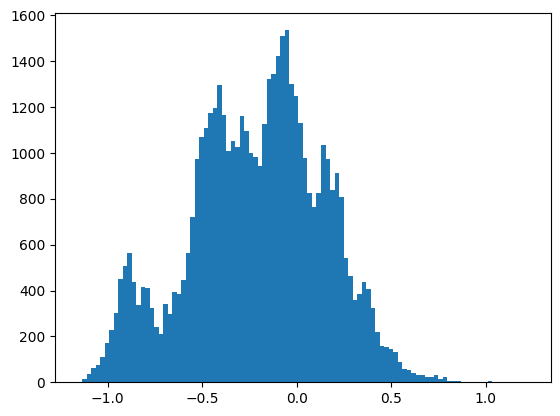

In [14]:
import numpy as np

potentials_dict_v2.values()
##print stats of vlaues
import matplotlib.pyplot as plt
# plt.hist(scores, bins=20)
plt.hist(potentials_dict_v2.values(), bins=100)
##summary min max quantiles

values = list(potentials_dict_v2.values())
print(f"Min: {min(values)}, Max: {max(values)}")
print(f"Quantiles: {[np.quantile(values, q) for q in [0.25, 0.5, 0.75]]}")

In [15]:
potentials_dict = potential.compute_with_identities(peptide, mutations)

# Get sequences above threshold
sequences, scores = potential.return_list_abovethreshold(
    parent_peptide=peptide,
    potentials=potentials_dict,
    mutations=mutations,
    threshold=-2  # optional, default is -0.5
)
print(len(sequences))

48383


In [16]:
sequences

['FLYKWWPRIGRLKL',
 'FLYKWWPRIGREKL',
 'FLYKWWIRHGRLKL',
 'FLYKWWIRIGREKL',
 'FLYKWWPRHGRLKL',
 'FLYKWWIRHGREKL',
 'FLYKWWPRHGREKL',
 'FLYKWWPRLGRLKL',
 'FLYKWWPRTGRLKL',
 'FLYKWWIRLGRLKL',
 'FLYKWWIRLGREKL',
 'FLRKWWIRHGRLKL',
 'FLYKWWIRTGREKL',
 'FLYKWWIRTGRLKL',
 'FLYKWWPRLGREKL',
 'FLYKWWPRTGREKL',
 'FLRKWWIRIGRLKL',
 'FLRKWWIRLGRLKL',
 'FLRKWWIRTGRLKL',
 'RLYKWWPRIGRLKL',
 'FLRKWWIRHGREKL',
 'PLYKWWPRIGRLKL',
 'RLYKWWPRIGREKL',
 'FLQKWWIRHGRLKL',
 'FLRKWWIRIGREKL',
 'FLYKWWIRHGRTKL',
 'FLRKWWPRHGRLKL',
 'RLYKWWIRIGREKL',
 'FLYKWWIRHGRKKL',
 'RLYKWWIRIGRLKL',
 'PLYKWWPRIGREKL',
 'FLRKWWPRIGRLKL',
 'FLYKWWLRHGRLKL',
 'FLRKWWIRLGREKL',
 'FLRKWWIRTGREKL',
 'PLYKWWIRIGREKL',
 'FLYKWWPRHGRTKL',
 'FLYKWWIRHGRLWL',
 'FLYWWWPRIGRLKL',
 'FLYWWWIRHGRLKL',
 'VLYKWWPRIGRLKL',
 'FLYWWWPRHGRLKL',
 'ILYKWWPRIGRLKL',
 'FLYKWWPRIGRLWL',
 'FLYKWWPRFGRLKL',
 'FLYKWWPRIGREWL',
 'FLYKWWPRFGREKL',
 'YLYKWWPRIGRLKL',
 'FLYWWWPRIGREKL',
 'FLRKWWIRHGRTKL',
 'FLRKWWPRLGRLKL',
 'FLYKWWPRHGRLWL',
 'FLYKWWPRPG

In [17]:
scores

[1.2268911202748616,
 1.176164280284535,
 1.1740524768829346,
 1.1661715507507324,
 1.1389759237116033,
 1.1146698865023525,
 1.0883477528889973,
 1.048645799810236,
 1.0405338460748845,
 1.0300343831380208,
 1.026026639071378,
 1.0184203061190518,
 1.017692739313299,
 1.0171655019124348,
 1.014707883199056,
 1.0077951431274415,
 0.9497917493184408,
 0.9475653388283469,
 0.9410098682750355,
 0.9186483729969371,
 0.869415283203125,
 0.8651317249644886,
 0.8605576833089192,
 0.8521134636618874,
 0.8470302061601118,
 0.8432511416348544,
 0.84214661916097,
 0.8402927572076971,
 0.8373076698996804,
 0.8365693887074789,
 0.8301636377970377,
 0.8186595223166726,
 0.8123280785300515,
 0.8100570678710938,
 0.8042856852213541,
 0.8010049299760298,
 0.7960033416748047,
 0.7931258461692117,
 0.792279676957564,
 0.7921819686889648,
 0.7910431948575106,
 0.7903600056966146,
 0.7891942804509943,
 0.788330771706321,
 0.7868072336370294,
 0.7861737569173177,
 0.78568115234375,
 0.7832166498357599,
 0.7

In [18]:
potential_normal = DecoderLogProbPotential(encoder_decoder=hydramp)

df = compose_mutant_distribution(
    parent_peptide=peptide,
    mutations=mutations,
    potential=potential_normal,
    include_parent_residue=True,
    top_k=50,
)

df

MutantDistribution(sequences=['FLYKWWIRIGRLKL', 'YLYKWWIRIGRLKL', 'FLYKWWIRIGRLWL', 'FLYWWWIRIGRLKL', 'FLYKWWPRIGRLKL', 'FLYKWWFRIGRLKL', 'FLYKWWIRPGRLKL', 'FLYKWWHRIGRLKL', 'RLYKWWIRIGRLKL', 'FLYKWWIRFGRLKL', 'FLRKWWIRIGRLKL', 'FLYKWWIRTGRLKL', 'FLYQWWIRIGRLKL', 'FLYKWWIRIGRNKL', 'FLYKWWTRIGRLKL', 'FLYKWWIRHGRLKL', 'FLYKWWIRLGRLKL', 'PLYKWWIRIGRLKL', 'FLFKWWIRIGRLKL', 'ILYKWWIRIGRLKL', 'HLYKWWIRIGRLKL', 'FLYKWWIRIGREKL', 'FLYKWWIRNGRLKL', 'FLYKWWIRIGRIKL', 'FLYKWWIRIGRTKL', 'VLYKWWIRIGRLKL', 'FLQKWWIRIGRLKL', 'CLYKWWIRIGRLKL', 'FLYKWWLRIGRLKL', 'YLYKWWIRIGRLWL', 'YLYWWWIRIGRLKL', 'FLYWWWIRIGRLWL', 'YLYKWWPRIGRLKL', 'FLYKWWPRIGRLWL', 'FLYKWWIRIGRKKL', 'YLYKWWFRIGRLKL', 'FLYKWWFRIGRLWL', 'YLYKWWIRPGRLKL', 'FLYKWWIRPGRLWL', 'FLYWWWPRIGRLKL', 'FLYWWWFRIGRLKL', 'YLYKWWHRIGRLKL', 'FLYKWWHRIGRLWL', 'FLYWWWIRPGRLKL', 'YLYKWWIRFGRLKL', 'RLYKWWIRIGRLWL', 'FLYKWWPRPGRLKL', 'FLYKWWIRFGRLWL', 'FLYKWWFRPGRLKL', 'YLRKWWIRIGRLKL'], log_potentials=array([-4.85178302e-05, -1.08812664e+01, -1.10113053e+

In [19]:
sequences[:50]

['FLYKWWPRIGRLKL',
 'FLYKWWPRIGREKL',
 'FLYKWWIRHGRLKL',
 'FLYKWWIRIGREKL',
 'FLYKWWPRHGRLKL',
 'FLYKWWIRHGREKL',
 'FLYKWWPRHGREKL',
 'FLYKWWPRLGRLKL',
 'FLYKWWPRTGRLKL',
 'FLYKWWIRLGRLKL',
 'FLYKWWIRLGREKL',
 'FLRKWWIRHGRLKL',
 'FLYKWWIRTGREKL',
 'FLYKWWIRTGRLKL',
 'FLYKWWPRLGREKL',
 'FLYKWWPRTGREKL',
 'FLRKWWIRIGRLKL',
 'FLRKWWIRLGRLKL',
 'FLRKWWIRTGRLKL',
 'RLYKWWPRIGRLKL',
 'FLRKWWIRHGREKL',
 'PLYKWWPRIGRLKL',
 'RLYKWWPRIGREKL',
 'FLQKWWIRHGRLKL',
 'FLRKWWIRIGREKL',
 'FLYKWWIRHGRTKL',
 'FLRKWWPRHGRLKL',
 'RLYKWWIRIGREKL',
 'FLYKWWIRHGRKKL',
 'RLYKWWIRIGRLKL',
 'PLYKWWPRIGREKL',
 'FLRKWWPRIGRLKL',
 'FLYKWWLRHGRLKL',
 'FLRKWWIRLGREKL',
 'FLRKWWIRTGREKL',
 'PLYKWWIRIGREKL',
 'FLYKWWPRHGRTKL',
 'FLYKWWIRHGRLWL',
 'FLYWWWPRIGRLKL',
 'FLYWWWIRHGRLKL',
 'VLYKWWPRIGRLKL',
 'FLYWWWPRHGRLKL',
 'ILYKWWPRIGRLKL',
 'FLYKWWPRIGRLWL',
 'FLYKWWPRFGRLKL',
 'FLYKWWPRIGREWL',
 'FLYKWWPRFGREKL',
 'YLYKWWPRIGRLKL',
 'FLYWWWPRIGREKL',
 'FLRKWWIRHGRTKL']

In [20]:
import numpy as np

## Compare sequences and scores for different values of n
# sequences, scores: from return_list_abovethreshold (pairwise similarity potential)
# df: from compose_mutant_distribution (decoder log prob potential)

print("Comparing Pairwise Similarity Potential vs Decoder Log Prob Potential\n")

# Extract sequences and scores from df (MutantDistribution namedtuple)
if hasattr(df, 'sequences') and hasattr(df, 'log_potentials'):
    # It's a MutantDistribution namedtuple
    df_sequences = list(df.sequences)
    df_scores = list(df.log_potentials) if isinstance(df.log_potentials, np.ndarray) else list(df.log_potentials)
else:
    # It's a DataFrame or dict
    if isinstance(df, dict):
        df_sequences = list(df.keys())
        df_scores = list(df.values())
    else:
        peptide_col = 'sequences' if 'sequences' in df.columns else ('peptide' if 'peptide' in df.columns else df.columns[0])
        score_col = 'log_potentials' if 'log_potentials' in df.columns else ('score' if 'score' in df.columns else df.columns[1])
        df_sequences = df[peptide_col].tolist()
        df_scores = df[score_col].tolist()

print(f"Data loaded:")
print(f"  Pairwise similarity: {len(sequences)} sequences")
print(f"  Decoder log prob: {len(df_sequences)} sequences")

# Create dictionaries for easy lookup
seq_scores_dict = {sequences[i]: scores[i] for i in range(len(sequences))}
df_scores_dict = {df_sequences[i]: df_scores[i] for i in range(len(df_sequences))}

# Simple correlation functions (Pearson only, no scipy needed)
def pearson_correlation(x, y):
    """Compute Pearson correlation coefficient."""
    x = np.array(x)
    y = np.array(y)
    n = len(x)
    if n < 2:
        return np.nan
    
    mean_x = np.mean(x)
    mean_y = np.mean(y)
    
    cov = np.sum((x - mean_x) * (y - mean_y))
    std_x = np.sqrt(np.sum((x - mean_x)**2))
    std_y = np.sqrt(np.sum((y - mean_y)**2))
    
    if std_x == 0 or std_y == 0:
        return np.nan
    
    return cov / (std_x * std_y)

# Compare for different n values
for n in [50, 100, 500, 1000]:
    # Adjust n if it exceeds available data
    n = min(n, len(sequences), len(df_sequences))
    
    if n < 2:
        continue
    
    # Get top n sequences from both sources
    seq_set_n = set(sequences[:n])
    df_set_n = set(df_sequences[:n])
    
    # Find overlap
    overlap = seq_set_n.intersection(df_set_n)
    
    print(f"\n{'='*60}")
    print(f"Comparison for top n={n}")
    print(f"{'='*60}")
    print(f"Peptides in both sources: {len(overlap)}/{n}")
    print(f"Overlap percentage: {100*len(overlap)/n:.1f}%")
    print(f"Only in pairwise similarity: {len(seq_set_n - df_set_n)}")
    print(f"Only in decoder log prob: {len(df_set_n - seq_set_n)}")
    
    # Show some examples
    if len(overlap) > 0:
        print(f"\nExample overlapping sequences (first 5):")
        for i, seq in enumerate(list(overlap)[:5]):
            print(f"  {seq}: pairwise={seq_scores_dict[seq]:.3f}, logprob={df_scores_dict[seq]:.3f}")
    
    # For overlapping sequences, compare scores
    if len(overlap) >= 2:
        # Get scores from both sources for overlapping sequences
        overlap_pairwise_scores = [seq_scores_dict[seq] for seq in overlap if seq in seq_scores_dict]
        overlap_logprob_scores = [df_scores_dict[seq] for seq in overlap if seq in df_scores_dict]
        
        # Filter out any inf or nan values
        valid_pairs = [(p, l) for p, l in zip(overlap_pairwise_scores, overlap_logprob_scores) 
                       if np.isfinite(p) and np.isfinite(l)]
        
        if len(valid_pairs) >= 2:
            overlap_pairwise_scores = [p for p, l in valid_pairs]
            overlap_logprob_scores = [l for p, l in valid_pairs]
            
            # Compute correlation
            pearson_corr = pearson_correlation(overlap_pairwise_scores, overlap_logprob_scores)
            
            print(f"\nScore correlation for {len(valid_pairs)} overlapping peptides:")
            print(f"  Pearson: {pearson_corr:.4f}")
        else:
            print(f"\nNot enough valid pairs ({len(valid_pairs)}) to compute correlation (need >= 2)")
    else:
        print(f"\nNot enough overlap ({len(overlap)}) to compute correlation")

print(f"\n{'='*60}")
print("Summary: These are two different ranking methods:")
print("  - Pairwise Similarity: Favors mutations that are geometrically aligned")
print("  - Decoder Log Prob: Favors mutations with high decoder probability")
print("They may produce different rankings based on different criteria.")

Comparing Pairwise Similarity Potential vs Decoder Log Prob Potential

Data loaded:
  Pairwise similarity: 48383 sequences
  Decoder log prob: 50 sequences

Comparison for top n=50
Peptides in both sources: 10/50
Overlap percentage: 20.0%
Only in pairwise similarity: 40
Only in decoder log prob: 40

Example overlapping sequences (first 5):
  YLYKWWPRIGRLKL: pairwise=0.783, logprob=-23.465
  FLYKWWIRTGRLKL: pairwise=1.017, logprob=-15.957
  FLRKWWIRIGRLKL: pairwise=0.950, logprob=-15.771
  RLYKWWIRIGRLKL: pairwise=0.837, logprob=-15.000
  FLYKWWPRIGRLKL: pairwise=1.227, logprob=-12.583

Score correlation for 10 overlapping peptides:
  Pearson: 0.7173

Comparison for top n=50
Peptides in both sources: 10/50
Overlap percentage: 20.0%
Only in pairwise similarity: 40
Only in decoder log prob: 40

Example overlapping sequences (first 5):
  YLYKWWPRIGRLKL: pairwise=0.783, logprob=-23.465
  FLYKWWIRTGRLKL: pairwise=1.017, logprob=-15.957
  FLRKWWIRIGRLKL: pairwise=0.950, logprob=-15.771
  RLYK

In [26]:
def return_above_2k(
    softmaxed_potentials: dict[tuple[int, ...], float],
    threshold: float | None = None,
) -> dict[tuple[int, ...], float]:
    """Return only mutants with probability >= threshold (default: 1 / number_of_potentials)."""
    if not softmaxed_potentials:
        return {}

    if threshold is None:
        threshold = 2.0 / len(softmaxed_potentials)

    filtered = {
        k: v for k, v in softmaxed_potentials.items() if v >= threshold
    }
    return dict(sorted(filtered.items(), key=lambda x: x[1], reverse=True))

In [27]:
above_2k = return_above_2k(softmaxed_potentials)
print(f"Candidates with p >= 2/N: {len(above_2k)}")

Candidates with p >= 2/N: 406


In [29]:
import numpy as np
import torch

from pep_compass.geometry.utils import metric_from_jac


def aa_tuple_to_sequence(
    aa_tuple: tuple[int, ...],
    base_peptide: str,
    positions: list[int],
    alphabet: list[str],
) -> str:
    chars = list(base_peptide)
    for local_i, aa_idx in enumerate(aa_tuple):
        chars[positions[local_i]] = alphabet[aa_idx]
    return "".join(chars)


# 1) Build ordered MUTANG sequence list and index map (for consistent indexing)
all_combos = list(potentials_dict_v2.keys())
all_sequences = [aa_tuple_to_sequence(c, peptide, positions, alphabet) for c in all_combos]
combo_to_index = {c: i for i, c in enumerate(all_combos)}

# 2) Encode start peptide + all generated peptides
z_start = hydramp.encode_peptides([peptide]).detach()

batch_size = 2048
all_latents = []
for i in range(0, len(all_sequences), batch_size):
    batch = all_sequences[i : i + batch_size]
    z_batch = hydramp.encode_peptides(batch).detach()
    all_latents.append(z_batch)
all_latents = torch.cat(all_latents, dim=0)

# 3) Local pullback Riemannian metric at starting peptide
jac_start = decoder_jacobian(
    lambda x: hydramp.decoder_forward(x, softmax=True, flatten=True),
    z_start,
    jacobian_fn_mode="approx",
    jacobian_fn_kwargs={"jacobian_eps": 1e-6},
)
g_start = metric_from_jac(jac_start)[0]  # (latent_dim, latent_dim)

# 4) Distances from start to all MUTANG peptides using d(z0, z)^2 = (z-z0)^T g(z0) (z-z0)
delta = all_latents - z_start  # broadcast over rows
dist2 = torch.einsum("bi,ij,bj->b", delta, g_start, delta)
all_distances = torch.sqrt(torch.clamp(dist2, min=0.0)).cpu().numpy()

# 5) Subset above 1/N softmax threshold, reusing global indexing
above_indices = [combo_to_index[c] for c in above_1k.keys() if c in combo_to_index]
above_distances = all_distances[above_indices] if len(above_indices) > 0 else np.array([])

mean_all = float(np.mean(all_distances)) if len(all_distances) > 0 else float("nan")
mean_above = float(np.mean(above_distances)) if len(above_distances) > 0 else float("nan")

print("Computed local Riemannian distances with consistent MUTANG indexing.")
print(f"Total MUTANG peptides: {len(all_sequences)}")
print(f"Peptides above 1/N threshold: {len(above_indices)}")
print(f"Mean distance(start -> all MUTANG): {mean_all:.6f}")
print(f"Mean distance(start -> MUTANG above 1/N): {mean_above:.6f}")

# Optional sanity check of indexing
print("\nFirst 5 indexed peptides and distances:")
for idx in range(min(5, len(all_sequences))):
    print(f"  idx={idx:5d}  dist={all_distances[idx]:.6f}  seq={all_sequences[idx]}")

Computed local Riemannian distances with consistent MUTANG indexing.
Total MUTANG peptides: 48383
Peptides above 1/N threshold: 22570
Mean distance(start -> all MUTANG): 0.001314
Mean distance(start -> MUTANG above 1/N): 0.001094

First 5 indexed peptides and distances:
  idx=    0  dist=0.000738  seq=CLFKWWFRFGREKL
  idx=    1  dist=0.000922  seq=CLFKWWFRFGREWL
  idx=    2  dist=0.000263  seq=CLFKWWFRFGRIKL
  idx=    3  dist=0.000435  seq=CLFKWWFRFGRIWL
  idx=    4  dist=0.000563  seq=CLFKWWFRFGRKKL


In [30]:
import numpy as np
import torch

from pep_compass.geometry.utils import metric_from_jac


def aa_tuple_to_sequence(
    aa_tuple: tuple[int, ...],
    base_peptide: str,
    positions: list[int],
    alphabet: list[str],
) -> str:
    chars = list(base_peptide)
    for local_i, aa_idx in enumerate(aa_tuple):
        chars[positions[local_i]] = alphabet[aa_idx]
    return "".join(chars)


# 1) Build ordered MUTANG sequence list and index map (for consistent indexing)
all_combos = list(potentials_dict_v2.keys())
all_sequences = [aa_tuple_to_sequence(c, peptide, positions, alphabet) for c in all_combos]
combo_to_index = {c: i for i, c in enumerate(all_combos)}

# 2) Encode start peptide + all generated peptides
z_start = hydramp.encode_peptides([peptide]).detach()

batch_size = 2048
all_latents = []
for i in range(0, len(all_sequences), batch_size):
    batch = all_sequences[i : i + batch_size]
    z_batch = hydramp.encode_peptides(batch).detach()
    all_latents.append(z_batch)
all_latents = torch.cat(all_latents, dim=0)

# 3) Local pullback Riemannian metric at starting peptide
jac_start = decoder_jacobian(
    lambda x: hydramp.decoder_forward(x, softmax=True, flatten=True),
    z_start,
    jacobian_fn_mode="approx",
    jacobian_fn_kwargs={"jacobian_eps": 1e-6},
)
g_start = metric_from_jac(jac_start)[0]  # (latent_dim, latent_dim)

# 4) Distances from start to all MUTANG peptides using d(z0, z)^2 = (z-z0)^T g(z0) (z-z0)
delta = all_latents - z_start  # broadcast over rows
dist2 = torch.einsum("bi,ij,bj->b", delta, g_start, delta)
all_distances = torch.sqrt(torch.clamp(dist2, min=0.0)).cpu().numpy()

# 5) Subset above 1/N softmax threshold, reusing global indexing
above_indices = [combo_to_index[c] for c in above_1k.keys() if c in combo_to_index]
above_distances = all_distances[above_indices] if len(above_indices) > 0 else np.array([])

mean_all = float(np.mean(all_distances)) if len(all_distances) > 0 else float("nan")
mean_above = float(np.mean(above_distances)) if len(above_distances) > 0 else float("nan")

print("Computed local Riemannian distances with consistent MUTANG indexing.")
print(f"Total MUTANG peptides: {len(all_sequences)}")
print(f"Peptides above 2/N threshold: {len(above_indices)}")
print(f"Mean distance(start -> all MUTANG): {mean_all:.6f}")
print(f"Mean distance(start -> MUTANG above 2/N): {mean_above:.6f}")

# Optional sanity check of indexing
print("\nFirst 5 indexed peptides and distances:")
for idx in range(min(5, len(all_sequences))):
    print(f"  idx={idx:5d}  dist={all_distances[idx]:.6f}  seq={all_sequences[idx]}")

Computed local Riemannian distances with consistent MUTANG indexing.
Total MUTANG peptides: 48383
Peptides above 2/N threshold: 22570
Mean distance(start -> all MUTANG): 0.001314
Mean distance(start -> MUTANG above 2/N): 0.001094

First 5 indexed peptides and distances:
  idx=    0  dist=0.000738  seq=CLFKWWFRFGREKL
  idx=    1  dist=0.000922  seq=CLFKWWFRFGREWL
  idx=    2  dist=0.000263  seq=CLFKWWFRFGRIKL
  idx=    3  dist=0.000435  seq=CLFKWWFRFGRIWL
  idx=    4  dist=0.000563  seq=CLFKWWFRFGRKKL
